In [22]:
# 标准库
import os
import sys
import json
import re
from pathlib import Path
from glob import glob

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [23]:
def parse_config_name(config_str):
    """
    把类似 'calib-arc_challenge_prompt-cot_method-WIFV_strategy-logistic_ratio-0.2'
    解析成 {'calib': 'arc_challenge', 'prompt': 'cot', 'method': 'WIFV', 'strategy': 'logistic', 'ratio': '0.2'}
    """
    parts = config_str.split("_")
    config_dict = {}
    current_key = None
    for part in parts:
        if "-" in part:
            key, val = part.split("-", 1)
            config_dict[key] = val
            current_key = key
        elif current_key:
            config_dict[current_key] += "_" + part  # 把长值合并
    return config_dict



In [24]:
def lm_eval_results_to_df(src) -> pd.DataFrame:
    if isinstance(src, (str, Path)):
        data = json.loads(Path(src).read_text())
    elif isinstance(src, dict):
        data = src
    else:
        raise TypeError("src 必须是文件路径或已解析 dict")

    rows = []
    order = {t: i for i, t in enumerate(data["results"].keys())}
    for task, res in data["results"].items():
        ver  = data.get("versions", {}).get(task, "")
        shot = data.get("n-shot", {}).get(task, "")
        hib  = data.get("higher_is_better", {}).get(task, {})
        for key, val in res.items():
            if "_stderr" in key or "," not in key:
                continue
            metric, flt = key.split(",", 1)
            stderr_key  = f"{metric}_stderr,{flt}"
            stderr_val  = res.get(stderr_key, None)

            # 构造 "value ± stderr" 字符串
            if stderr_val is not None:
                value_str = f"{val:.4f} ± {stderr_val:.4f}"
            else:
                value_str = f"{val:.4f}"

            rows.append(
                dict(
                    Task=task,
                    Version=ver,
                    Filter=flt,
                    Shot=shot,
                    Metric=metric,
                    Arrow="↑" if hib.get(metric, True) else "↓",
                    Value=val,
                    Stderr=stderr_val,
                    Display=value_str,
                    _order=order[task],
                )
            )

    return (
        pd.DataFrame(rows)
          .sort_values(["_order", "Metric"])
          .drop(columns="_order")
          .reset_index(drop=True)
    )



In [25]:
def collect_eval_results(root_dir, patterns=None):
    """
    支持多个匹配规则（__tmp__ 和 origan），每个目录仅保留最新（文件名靠后）的 JSON 文件。
    """
    if patterns is None:
        patterns = [
            "**/.__tmp__*/results_*.json",  # 校准结果
            "**/origan/**/results_*.json",  # 原始模型结果
        ]

    root_dir = Path(root_dir)
    all_candidates = []

    for pat in patterns:
        matched = sorted(glob(str(root_dir / pat), recursive=True))
        all_candidates += matched

    if not all_candidates:
        raise FileNotFoundError(f"未在 {root_dir} 中找到匹配结果文件")

    # 1. 按目录分组
    files_by_dir = {}
    for f in all_candidates:
        dir_path = str(Path(f).parent)
        files_by_dir.setdefault(dir_path, []).append(f)

    # 2. 每个目录只保留文件名最大的那个
    latest_files = []
    for file_list in files_by_dir.values():
        latest_file = max(file_list, key=lambda p: Path(p).name)
        latest_files.append(latest_file)

    all_frames = []
    for fp in latest_files:
        try:
            df = lm_eval_results_to_df(fp)
        except Exception as e:
            print(f"⚠️ 跳过无效文件 {fp}: {e}")
            continue

        parts = Path(fp).parts
        try:
            model_name = parts[-4]
            config_name = parts[-3]
        except IndexError:
            model_name, config_name = "", ""

        config_parts = {"prompt": "original"} if "origan" in parts else parse_config_name(config_name)

        df["Model"] = model_name
        for k, v in config_parts.items():
            df[k] = v

        all_frames.append(df)

    result = pd.concat(all_frames, ignore_index=True)
    return result.sort_values(by=["Task", "Metric", "Value"], ascending=[True, True, False]).reset_index(drop=True)


In [26]:
# ========== 使用 ==========
root = "/mnt/public/code/hanyu/codes/SEAP/eval_out"
df_all = collect_eval_results(root)

# 可选统一格式
pd.options.display.float_format = "{:.4f}".format
df_all

,Task,Version,Filter,Shot,Metric,Arrow,Value,Stderr,Display,Model,calib,prompt,method,strategy,ratio
0,arc_challenge,1.0000,none,0,acc,↑,0.4224,0.0144,0.4224 ± 0.0144,Llama-2-7b-hf,arc_easy,corpus,WIFV,logistic,0.2
1,arc_challenge,1.0000,none,0,acc,↑,0.4215,0.0144,0.4215 ± 0.0144,Llama-2-7b-hf,arc_easy,knowledge,WIFV,logistic,0.2
2,arc_challenge,1.0000,none,0,acc,↑,0.4164,0.0144,0.4164 ± 0.0144,Llama-2-7b-hf,arc_challenge,corpus,WIFV,logistic,0.2
3,arc_challenge,1.0000,none,0,acc,↑,0.4113,0.0144,0.4113 ± 0.0144,Llama-2-7b-hf,openbookqa,knowledge,WIFV,logistic,0.2
4,arc_challenge,1.0000,none,0,acc,↑,0.4104,0.0144,0.4104 ± 0.0144,Llama-2-7b-hf,boolq,corpus,WIFV,logistic,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1147,winogrande,1.0000,none,0,acc,↑,0.6219,0.0136,0.6219 ± 0.0136,Llama-2-7b-hf,hellaswag,icl,WIFV,logistic,0.2
1148,winogrande,1.0000,none,0,acc,↑,0.6196,0.0136,0.6196 ± 0.0136,Llama-2-7b-hf,arc_easy,zero_shot,WIFV,logistic,0.2
1149,winogrande,1.0000,none,0,acc,↑,0.6125,0.0137,0.6125 ± 0.0137,Llama-2-7b-hf,mathqa,zero_shot,WIFV,logistic,0.2
1150,winogrande,1.0000,none,0,acc,↑,0.6109,0.0137,0.6109 ± 0.0137,Llama-2-7b-hf,mathqa,icl,WIFV,logistic,0.2


In [27]:
df_all[df_all['Task']== 'gsm8k']

,Task,Version,Filter,Shot,Metric,Arrow,Value,Stderr,Display,Model,calib,prompt,method,strategy,ratio
320,gsm8k,3.0000,flexible-extract,5,exact_match,↑,0.0788,0.0074,0.0788 ± 0.0074,Llama-2-7b-hf,gsm8k,knowledge,WIFV,logistic,0.2
321,gsm8k,3.0000,strict-match,5,exact_match,↑,0.0720,0.0071,0.0720 ± 0.0071,Llama-2-7b-hf,gsm8k,knowledge,WIFV,logistic,0.2
322,gsm8k,3.0000,flexible-extract,5,exact_match,↑,0.0713,0.0071,0.0713 ± 0.0071,Llama-2-7b-hf,mathqa,corpus,WIFV,logistic,0.2
323,gsm8k,3.0000,flexible-extract,5,exact_match,↑,0.0705,0.0071,0.0705 ± 0.0071,Llama-2-7b-hf,mathqa,cot,WIFV,logistic,0.2
324,gsm8k,3.0000,flexible-extract,5,exact_match,↑,0.0697,0.0070,0.0697 ± 0.0070,Llama-2-7b-hf,gsm8k,icl,WIFV,logistic,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443,gsm8k,3.0000,strict-match,5,exact_match,↑,0.0000,0.0000,0.0000 ± 0.0000,Llama-2-7b-hf,openbookqa,knowledge,WIFV,logistic,0.2
444,gsm8k,3.0000,strict-match,5,exact_match,↑,0.0000,0.0000,0.0000 ± 0.0000,Llama-2-7b-hf,piqa,corpus,WIFV,logistic,0.2
445,gsm8k,3.0000,strict-match,5,exact_match,↑,0.0000,0.0000,0.0000 ± 0.0000,Llama-2-7b-hf,piqa,knowledge,WIFV,logistic,0.2
446,gsm8k,3.0000,strict-match,5,exact_match,↑,0.0000,0.0000,0.0000 ± 0.0000,Llama-2-7b-hf,winogrande,corpus,WIFV,logistic,0.2


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_prompt_heatmap(
    df,
    prompt_type="knowledge",
    normalize=True,
    task_groups=None,
    figsize=(9, 6),
    model_name=None  
):
    """
    绘制任务热力图，显示不同 prompt_type 在各任务上的效果变化。

    - 对 gsm8k 使用 exact_match，其它任务使用 acc；
    - 支持标准化为相对变化率 ((val - base) / base)，并限制显示范围在 [-0.5, 0.5]；
    - 红=性能下降，白=无变化，蓝=性能上升。
    """
    if model_name:
        df = df[df["Model"] == model_name].copy()

    df = df[df["prompt"] == prompt_type].copy()

    if task_groups is None:
        task_groups = {
            "code_gen": ["humaneval", "mbpp"],
            "math_reasoning": ["gsm8k", "mathqa"],
            "comparison": ["boolq", "race"],
            "knowledge_qa": ["arc_challenge", "arc_easy", "openbookqa"],
            "commonsense": ["piqa", "winogrande", "hellaswag"],
            "language_model": ["c4", "wikitext2"],
        }

    ordered_tasks = [task for group in task_groups.values() for task in group]

    df["Metric_for_use"] = df.apply(
        lambda row: (
            "pass_at_1" if row["Task"] == "mbpp"
            else "pass@1" if row["Task"] == "humaneval"
            else "exact_match" if row["Task"] == "gsm8k"
            else row["Metric"]
        ),
        axis=1
    )
    df_filtered = df[df["Metric_for_use"].isin(["acc", "exact_match", "pass@1", "pass_at_1"])]

    pivot = df_filtered.pivot_table(
        index="Task", columns="calib", values="Value", aggfunc="mean"
    )

    task_set = set(pivot.index)
    calib_set = set(pivot.columns)
    common = list(task_set & calib_set)

    aligned = [t for t in ordered_tasks if t in common]
    row_only = [t for t in pivot.index if t not in aligned]
    col_only = [t for t in pivot.columns if t not in aligned]

    row_order = aligned + row_only
    col_order = aligned + col_only

    pivot = pivot.reindex(index=row_order, columns=col_order)

    # 标准化为相对变化率
    if normalize:
        norm_pivot = pivot.copy()
        for task in pivot.index:
            if task in pivot.columns:
                try:
                    base = pivot.at[task, task]
                    for calib in pivot.columns:
                        val = pivot.at[task, calib]
                        if pd.isna(val) or pd.isna(base):
                            norm_pivot.at[task, calib] = float("nan")
                        elif base == 0 or val == 0:
                            norm_pivot.at[task, calib] = -1.0
                        else:
                            norm_pivot.at[task, calib] = (val - base) / base
                except Exception as e:
                    print(f"⚠️ 基准提取失败 {task}: {e}")
                    norm_pivot.loc[task] = float("nan")
            else:
                norm_pivot.loc[task] = float("nan")
        pivot = norm_pivot

    # 绘图
    plt.figure(figsize=figsize)
    sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="Blues_r",
    vmin=-0.08,
    vmax=0.08,
    cbar_kws={"label": "Relative Change" if normalize else "Accuracy"}
    )
    plt.title(f"Prompt Type: {prompt_type} ({'Relative Δ' if normalize else 'Raw Acc'})")
    plt.xlabel("Calibration Task")
    plt.ylabel("Test Task")
    plt.tight_layout()
    plt.show()

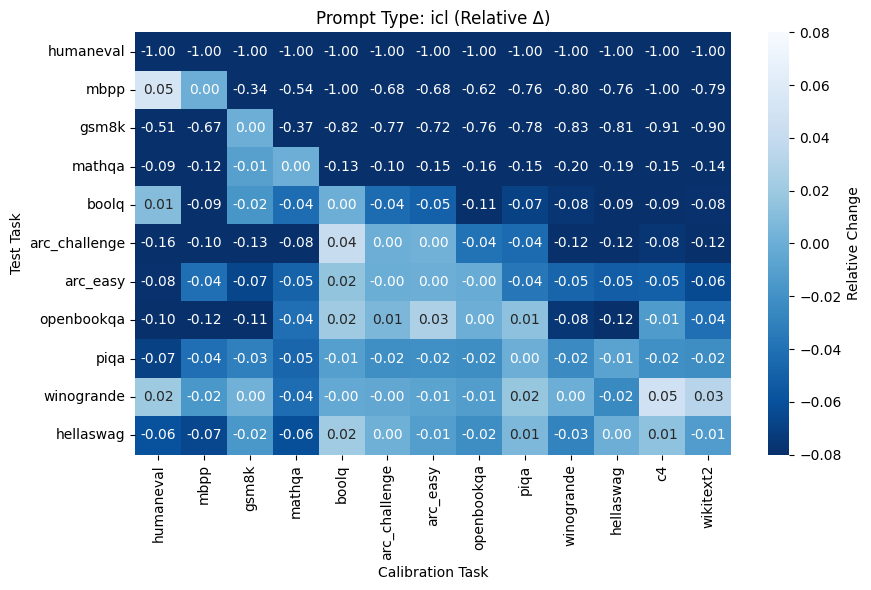

In [33]:
plot_prompt_heatmap(df_all, prompt_type="icl", model_name="Llama-2-7b-hf")    # 标准化后热力图


In [30]:
output_path = "/mnt/public/code/hanyu/codes/SEAP/eval_summary.xlsx"
df_all.to_excel(output_path, index=False)

print(f"Saved: {output_path}")

Saved: /mnt/public/code/hanyu/codes/SEAP/eval_summary.xlsx
